## This is how Bagging/RandomForest works Internally By Using Feature Sampling

### Importing Libraries

In [99]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

#### Generating a Synthetic Classification Dataset

In [100]:
X , y = make_classification(n_features=5, n_informative=5, n_redundant=0, n_clusters_per_class=1)

In [101]:
df = pd.DataFrame(X , columns=['col1', 'col2' , 'col3', 'col4', 'col5'])
df['target'] = y

In [102]:
df.shape

(100, 6)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col1    100 non-null    float64
 1   col2    100 non-null    float64
 2   col3    100 non-null    float64
 3   col4    100 non-null    float64
 4   col5    100 non-null    float64
 5   target  100 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 4.8 KB


In [104]:
df.head()

,col1,col2,col3,col4,col5,target
0,-0.008796,0.158807,-0.031135,-1.095850,1.668843,0
1,0.556325,0.541616,-0.956213,-0.357238,-3.268976,1
2,-0.373371,-0.968847,-2.090837,1.206841,0.035888,0
3,2.462728,-1.380659,-0.064968,-2.881381,-0.317294,1
4,1.435208,-1.700143,1.151971,-1.452379,1.380730,1


### Function for features/columns Sampling

In [105]:
def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

### Using Feature sampling

#### `RandomForest` is collection of decision tree 
Now we will Create 3 new datasets using Feature Sampling With Replacement

In [106]:
df1 = sample_features(df,0.8)
df1

C:\Users\hb292\AppData\Local\Temp\ipykernel_25252\1964868790.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col1,col3,col2,col4,target
0,-0.008796,-0.031135,0.158807,-1.095850,0
1,0.556325,-0.956213,0.541616,-0.357238,1
2,-0.373371,-2.090837,-0.968847,1.206841,0
3,2.462728,-0.064968,-1.380659,-2.881381,1
4,1.435208,1.151971,-1.700143,-1.452379,1
...,...,...,...,...,...
95,-0.281272,2.026543,-1.122527,0.019731,1
96,2.384734,0.258522,-1.473860,-1.090149,1
97,-2.294082,-0.219218,2.077273,-1.107456,0
98,1.956227,0.848692,-0.506802,-4.113369,1


In [107]:
df2 = sample_features(df,0.8)
df2

C:\Users\hb292\AppData\Local\Temp\ipykernel_25252\1964868790.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col1,col2,col5,col3,target
0,-0.008796,0.158807,1.668843,-0.031135,0
1,0.556325,0.541616,-3.268976,-0.956213,1
2,-0.373371,-0.968847,0.035888,-2.090837,0
3,2.462728,-1.380659,-0.317294,-0.064968,1
4,1.435208,-1.700143,1.380730,1.151971,1
...,...,...,...,...,...
95,-0.281272,-1.122527,2.559320,2.026543,1
96,2.384734,-1.473860,-0.722890,0.258522,1
97,-2.294082,2.077273,0.669518,-0.219218,0
98,1.956227,-0.506802,0.927331,0.848692,1


In [108]:
df3 = sample_features(df,0.8)
df3

C:\Users\hb292\AppData\Local\Temp\ipykernel_25252\1964868790.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col4,col5,col2,col1,target
0,-1.095850,1.668843,0.158807,-0.008796,0
1,-0.357238,-3.268976,0.541616,0.556325,1
2,1.206841,0.035888,-0.968847,-0.373371,0
3,-2.881381,-0.317294,-1.380659,2.462728,1
4,-1.452379,1.380730,-1.700143,1.435208,1
...,...,...,...,...,...
95,0.019731,2.559320,-1.122527,-0.281272,1
96,-1.090149,-0.722890,-1.473860,2.384734,1
97,-1.107456,0.669518,2.077273,-2.294082,0
98,-4.113369,0.927331,-0.506802,1.956227,1


In [109]:
print(f"""    {df1.columns},
      {df2.columns},
      {df3.columns}""")

    Index(['col1', 'col3', 'col2', 'col4', 'target'], dtype='object'),
      Index(['col1', 'col2', 'col5', 'col3', 'target'], dtype='object'),
      Index(['col4', 'col5', 'col2', 'col1', 'target'], dtype='object')


#### calling decisiontreeClassifier and making objects for my 3 datasets 

In [110]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [111]:
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### ploting 3 decision tree by row sampling

In [112]:
from sklearn.tree import plot_tree

[Text(0.43333333333333335, 0.9166666666666666, 'x[1] <= 0.455\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.13333333333333333, 0.75, 'x[0] <= 0.359\ngini = 0.316\nsamples = 56\nvalue = [45, 11]'),
 Text(0.2833333333333333, 0.8333333333333333, 'True  '),
 Text(0.06666666666666667, 0.5833333333333334, 'gini = 0.0\nsamples = 42\nvalue = [42, 0]'),
 Text(0.2, 0.5833333333333334, 'x[2] <= -0.763\ngini = 0.337\nsamples = 14\nvalue = [3, 11]'),
 Text(0.13333333333333333, 0.4166666666666667, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.26666666666666666, 0.4166666666666667, 'x[1] <= -0.075\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.2, 0.25, 'x[3] <= -2.357\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.13333333333333333, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.26666666666666666, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.3333333333333333, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.73

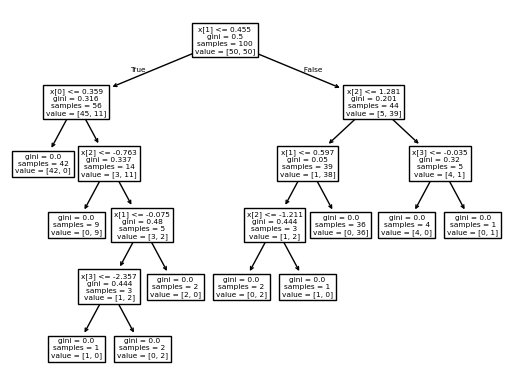

In [113]:
plot_tree(clf1)

[Text(0.4230769230769231, 0.9, 'x[3] <= 0.455\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.15384615384615385, 0.7, 'x[0] <= 0.359\ngini = 0.316\nsamples = 56\nvalue = [45, 11]'),
 Text(0.28846153846153844, 0.8, 'True  '),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 42\nvalue = [42, 0]'),
 Text(0.23076923076923078, 0.5, 'x[2] <= 0.565\ngini = 0.337\nsamples = 14\nvalue = [3, 11]'),
 Text(0.15384615384615385, 0.3, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.3076923076923077, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6923076923076923, 0.7, 'x[1] <= 1.281\ngini = 0.201\nsamples = 44\nvalue = [5, 39]'),
 Text(0.5576923076923077, 0.8, '  False'),
 Text(0.5384615384615384, 0.5, 'x[3] <= 0.597\ngini = 0.05\nsamples = 39\nvalue = [1, 38]'),
 Text(0.46153846153846156, 0.3, 'x[1] <= -1.211\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.38461538461538464, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.5384615384615384, 0.1, 'gini = 0.

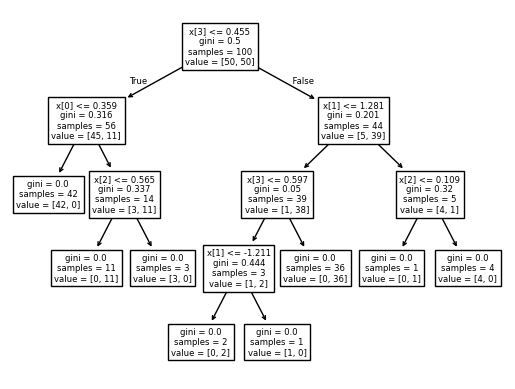

In [114]:
plot_tree(clf2)

[Text(0.5892857142857143, 0.9285714285714286, 'x[3] <= 0.211\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.27380952380952384, 0.7857142857142857, 'x[0] <= -0.226\ngini = 0.371\nsamples = 57\nvalue = [43, 14]'),
 Text(0.43154761904761907, 0.8571428571428572, 'True  '),
 Text(0.09523809523809523, 0.6428571428571429, 'x[1] <= 2.477\ngini = 0.114\nsamples = 33\nvalue = [31, 2]'),
 Text(0.047619047619047616, 0.5, 'gini = 0.0\nsamples = 30\nvalue = [30, 0]'),
 Text(0.14285714285714285, 0.5, 'x[1] <= 2.928\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.09523809523809523, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.19047619047619047, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.4523809523809524, 0.6428571428571429, 'x[3] <= -1.061\ngini = 0.5\nsamples = 24\nvalue = [12, 12]'),
 Text(0.3333333333333333, 0.5, 'x[0] <= 1.408\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.2857142857142857, 0.35714285714285715, 'gini =

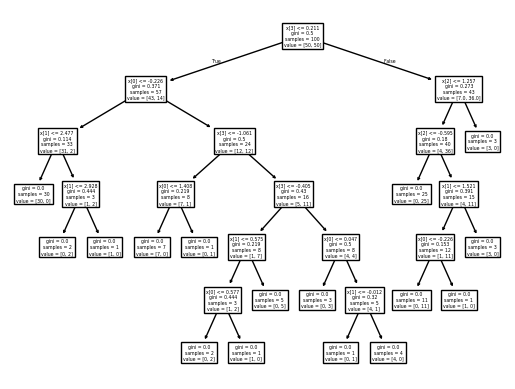

In [115]:
plot_tree(clf3)

### we will predict a random datapoint manually to see how the each Decision Tree is Predicting 


In [116]:
clf1.predict(np.array([-0.008796,	0.158807,	1.668843,	-0.031135]).reshape(1,4))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [117]:
clf2.predict(np.array([-0.008796,	0.158807,	1.668843,	-0.031135]).reshape(1,4))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [118]:
clf3.predict(np.array([-0.008796,	0.158807,	1.668843,	-0.031135]).reshape(1,4))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

#### Query point Answer should be `0` so 2 tree predicted correctly and 1 tree predicted `1`